<a href="https://colab.research.google.com/github/vrishank-ramineni/ECON3916---Statistics-Machine-Learning/blob/main/Assignment_4_The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.eval_measures import rmse
from statsmodels.stats.diagnostic import het_white
!pip install category_encoders
import category_encoders as ce
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12
})


## Step 1.1: The Omitted Confounder — Fork DAG

### The Spurious Correlation
The beta model found a significant positive correlation between
`Inpatient_Admission_Rate` and `High_Deductible_Insurance_Plan`. The
marketing team interprets this as: high-deductible plans *cause* more
admissions (via delayed preventive care).

### The True Causal Structure: A Fork (Common Cause)

```
            Socioeconomic_Status (U)
              ↙                ↘
High_Deductible_Plan    Inpatient_Admission_Rate
```

**The omitted confounder is Socioeconomic Status (systemic poverty).**

- **U → High_Deductible_Plan:** Lower-income patients are more likely to
  be enrolled in high-deductible plans because employers in low-wage
  industries disproportionately offer these cheaper plans, and individuals
  on the ACA marketplace select them due to lower premiums.

- **U → Inpatient_Admission_Rate:** Poverty independently drives higher
  admission rates through food insecurity, environmental exposure, limited
  access to outpatient care, and chronic stress — all of which worsen
  baseline health regardless of insurance structure.

### Why the Naive Regression is Biased

The OVB formula for the coefficient on `High_Deductible_Plan`:

$$\hat{\beta}_{naive} = \beta_{true} + \beta_{SES} \times \delta_{SES \rightarrow Plan}$$

Where:
- β_SES > 0 (poverty increases admissions)
- δ_SES→Plan > 0 (poverty predicts high-deductible enrollment)

The bias term is **positive**, inflating the naive coefficient. The model
incorrectly attributes the poverty-driven admission risk to the insurance
plan itself. Without controlling for SES, the predictive weight on
`High_Deductible_Plan` is mathematically contaminated — any pricing
algorithm using this weight would systematically overcharge patients
on high-deductible plans.

In [ ]:
df_vitals = pd.read_csv('OmniCare_Clinical_Vitals.csv')

print(f"Clinical Vitals — Shape: {df_vitals.shape}")
print(f"Columns: {df_vitals.columns.tolist()}")
display(df_vitals.head())

vif_features = ['Weight_kg', 'Height_cm', 'BMI', 'Systolic_BP', 'Diastolic_BP']

vif_features = [c for c in vif_features if c in df_vitals.columns]
print(f"\nVIF features found: {vif_features}")

df_vif = df_vitals[vif_features].dropna()

X_vif = sm.add_constant(df_vif)

vif_df = pd.DataFrame()
vif_df['Feature'] = X_vif.columns
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i)
                 for i in range(X_vif.shape[1])]

vif_df = vif_df[vif_df['Feature'] != 'const']

print("\n" + "=" * 50)
print("VIF AUDIT — BEFORE DROPPING")
print("=" * 50)
display(vif_df.sort_values('VIF', ascending=False))

critical = vif_df[vif_df['VIF'] > 10.0]
print(f"\n⚠  Features with VIF > 10.0:")
display(critical)

drop_col = 'BMI'
print(f"\n→ Dropping '{drop_col}' (derived from Weight & Height by construction)")

vif_features_clean = [c for c in vif_features if c != drop_col]
df_vif_clean = df_vitals[vif_features_clean].dropna()
X_vif_clean = sm.add_constant(df_vif_clean)

vif_df_clean = pd.DataFrame()
vif_df_clean['Feature'] = X_vif_clean.columns
vif_df_clean['VIF'] = [variance_inflation_factor(X_vif_clean.values, i)
                        for i in range(X_vif_clean.shape[1])]
vif_df_clean = vif_df_clean[vif_df_clean['Feature'] != 'const']

print("\n" + "=" * 50)
print("VIF AUDIT — AFTER DROPPING BMI")
print("=" * 50)
display(vif_df_clean.sort_values('VIF', ascending=False))

if (vif_df_clean['VIF'] <= 10.0).all():
    print("\n✓ All VIFs below 10.0 — multicollinearity resolved.")
else:
    print("\n⚠  Some VIFs still above 10.0 — further action needed.")



Clinical Vitals — Shape: (5000, 6)
Columns: ['Patient_ID', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP']


,Patient_ID,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP
0,1000,177.5,66.3,21.06,110.0,75.0
1,1001,167.9,57.5,20.39,115.0,79.0
2,1002,179.7,57.4,17.77,111.0,77.0
3,1003,192.8,80.9,21.76,122.0,88.0
4,1004,166.5,65.7,23.70,138.0,89.0



VIF features found: ['Weight_kg', 'Height_cm', 'BMI', 'Systolic_BP', 'Diastolic_BP']

VIF AUDIT — BEFORE DROPPING


,Feature,VIF
1,Weight_kg,57.428058
2,Height_cm,28.419446
3,BMI,16.981232
5,Diastolic_BP,4.219820
4,Systolic_BP,4.219406



⚠  Features with VIF > 10.0:


,Feature,VIF
1,Weight_kg,57.428058
2,Height_cm,28.419446
3,BMI,16.981232



→ Dropping 'BMI' (derived from Weight & Height by construction)

VIF AUDIT — AFTER DROPPING BMI


,Feature,VIF
4,Diastolic_BP,4.219820
3,Systolic_BP,4.219406
1,Weight_kg,3.763969
2,Height_cm,3.763812



✓ All VIFs below 10.0 — multicollinearity resolved.


Telemetry Data — Shape: (5000, 8)
Columns: ['Patient_ID', 'High_Deductible_Insurance_Plan', 'Inpatient_Admission_Rate', 'Continuous_Heart_Rate', 'Primary_Diagnosis_Code', 'Clinic_Capacity_Percentage', 'Time_of_Day_Index', 'Procedure_Cost_USD']


,Missing,% Missing
Continuous_Heart_Rate,1214,24.28


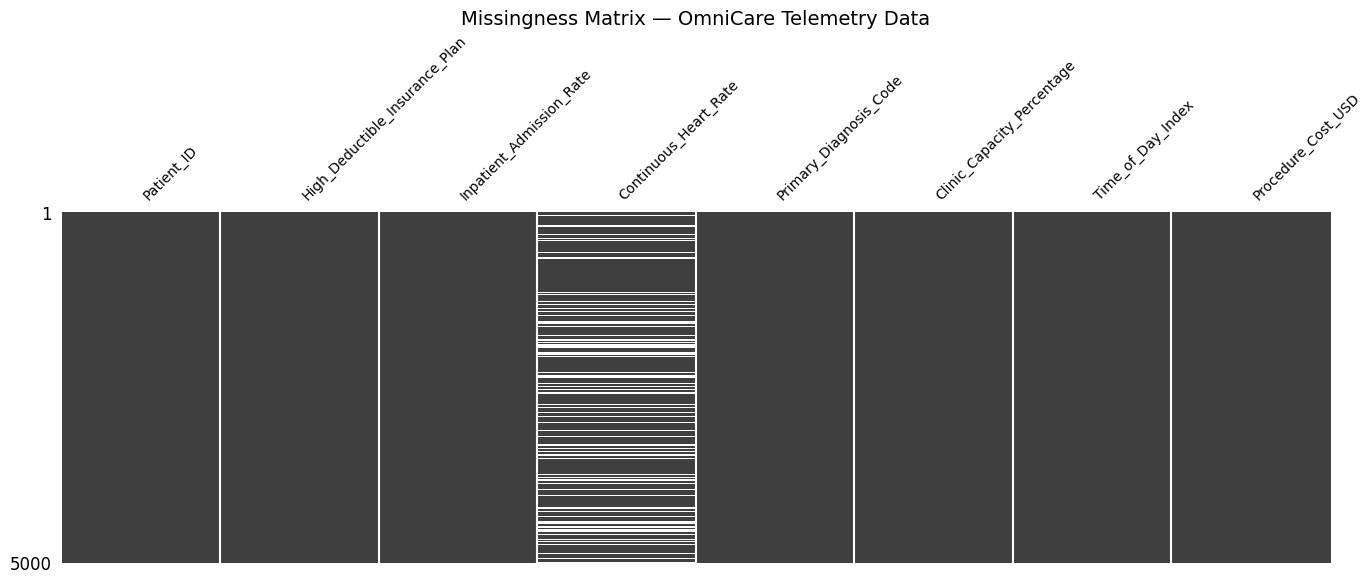

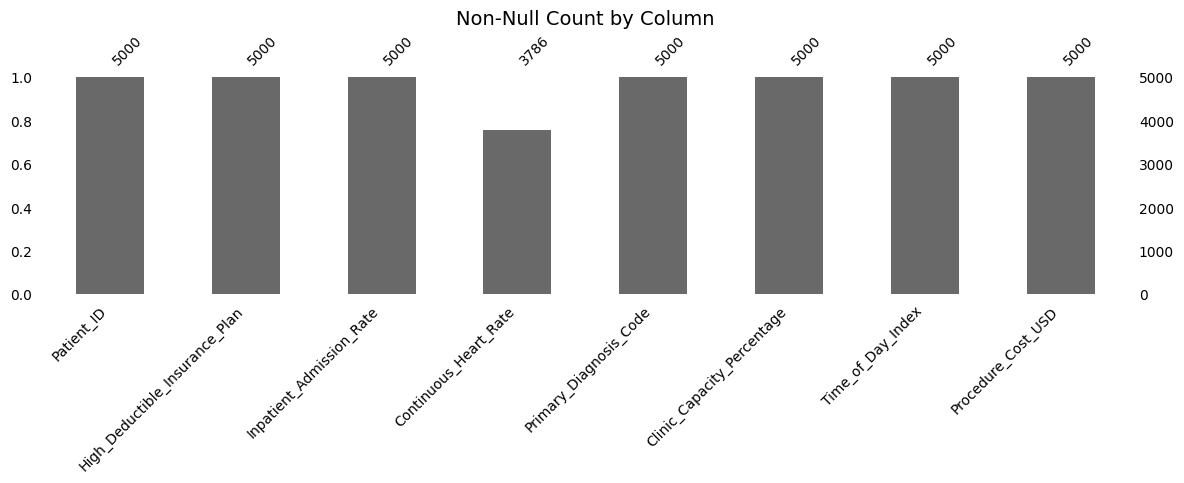

In [ ]:
df_telemetry = pd.read_csv('OmniCare_Telemetry_Data.csv')

print(f"Telemetry Data — Shape: {df_telemetry.shape}")
print(f"Columns: {df_telemetry.columns.tolist()}")

missing = df_telemetry.isnull().sum()
missing_pct = (missing / len(df_telemetry) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing': missing, '% Missing': missing_pct
}).sort_values('% Missing', ascending=False)
display(missing_report[missing_report['Missing'] > 0])

fig, ax = plt.subplots(figsize=(14, 6))
msno.matrix(df_telemetry, ax=ax, fontsize=10, sparkline=False)
ax.set_title('Missingness Matrix — OmniCare Telemetry Data', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
msno.bar(df_telemetry, ax=ax, fontsize=10)
ax.set_title('Non-Null Count by Column', fontsize=14)
plt.tight_layout()
plt.show()

## Step 2.1 Analysis: Rubin's Taxonomy — MNAR Classification

### The Scenario
Low-income patients systematically refuse to transmit continuous heart
rate data because of the cellular data costs associated with real-time
wearable streaming.

### Classification: **MNAR (Missing Not at Random)**

This is MNAR — not MCAR or MAR — because the probability of missingness
depends on the **unobserved value itself**:

- **Not MCAR:** Missingness is not random. It is systematically concentrated
  among low-income patients — a specific, identifiable subpopulation.

- **Not MAR:** MAR requires that missingness is fully explained by other
  *observed* variables in the dataset. Here, the mechanism is income →
  data-plan affordability → transmission refusal. If income is not observed
  in the dataset, the missingness is driven by an *unobserved* variable
  and cannot be conditioned away.

- **MNAR:** The patients whose heart rate data is missing are precisely
  those whose health profiles are likely *most different* from the observed
  patients. Low-income patients have higher baseline cardiovascular risk
  (hypertension, chronic stress), meaning the missing heart rate values
  are systematically higher/more abnormal than the observed values.

### Why Mean Imputation Destroys Integrity

Mean imputation replaces missing values with the sample mean of the
*observed* data. But the observed data is a **biased subsample** — it
over-represents healthier, wealthier patients whose wearables are
transmitting. The imputed mean will be:

- **Too low** (underestimating true heart rate for missing patients)
- **Artificially compress variance** (shrinking the distribution toward
  the center)
- **Bias every downstream coefficient** that uses heart rate as a
  predictor — the algorithm will systematically underestimate risk for
  the very patients who are most at risk

The result: a pricing algorithm that is both **clinically dangerous**
(underpricing risk for vulnerable populations) and **legally indefensible**
(disparate impact on low-income patients).

## Step 2.2: Escaping the Dummy Variable Trap — Matrix Algebra Proof

### The Setup
`Primary_Diagnosis_Code` contains 850 distinct ICD-10 strings. A junior
analyst applies `pd.get_dummies()`, creating 850 binary columns
(D₁, D₂, ..., D₈₅₀).

The design matrix becomes: **X = [1, D₁, D₂, ..., D₈₅₀, other features]**

### The Trap: Perfect Multicollinearity

For any observation, exactly ONE of the 850 dummies equals 1, and the
rest equal 0. Therefore:

$$D_1 + D_2 + D_3 + \cdots + D_{850} = \mathbf{1}$$

The sum of all 850 dummy columns is **identically equal to the intercept
column** (a vector of ones). This means:

$$\mathbf{1} = \sum_{k=1}^{850} D_k$$

### Why OLS Breaks

The OLS estimator is: $\hat{\beta} = (X^T X)^{-1} X^T y$

For this to exist, $(X^T X)$ must be **invertible** (non-singular). But
since the intercept column is a perfect linear combination of the dummy
columns, the columns of X are **linearly dependent**. This means:

- $\text{rank}(X) < p$ (not full column rank)
- $\det(X^T X) = 0$ (singular matrix)
- $(X^T X)^{-1}$ **does not exist**

The OLS estimator is mathematically undefined. The system has infinitely
many solutions — there is no unique set of coefficients that minimizes
the sum of squared residuals.

### The Fix
Drop one dummy category (the "reference group"), so the remaining 849
dummies are linearly independent of the intercept. Or, use Target
Encoding (Step 2.3) to collapse all 850 categories into a single
continuous variable.

In [ ]:
print("Unique diagnosis codes:", df_telemetry['Primary_Diagnosis_Code'].nunique())

encoder = ce.TargetEncoder(cols=['Primary_Diagnosis_Code'])
df_telemetry['Target_Encoded_Diagnosis'] = encoder.fit_transform(
    df_telemetry['Primary_Diagnosis_Code'],
    df_telemetry['Procedure_Cost_USD']
)

print("\nTarget Encoding — First 5 Rows:")
display(df_telemetry[['Primary_Diagnosis_Code', 'Target_Encoded_Diagnosis',
                       'Procedure_Cost_USD']].head())

print(f"\nDimensionality: 850 ICD-10 strings → 1 continuous column")
print(f"Encoded column stats:")
print(f"  Mean:  ${df_telemetry['Target_Encoded_Diagnosis'].mean():,.2f}")
print(f"  Std:   ${df_telemetry['Target_Encoded_Diagnosis'].std():,.2f}")

Unique diagnosis codes: 847

Target Encoding — First 5 Rows:


,Primary_Diagnosis_Code,Target_Encoded_Diagnosis,Procedure_Cost_USD
0,J86.381,1707.697108,1635.84
1,M29.789,1792.303198,1355.77
2,E49.618,1730.334968,1189.19
3,E66.244,1725.060944,1250.93
4,J45.553,1801.821085,1986.34



Dimensionality: 850 ICD-10 strings → 1 continuous column
Encoded column stats:
  Mean:  $1,755.34
  Std:   $33.01


In [ ]:
shared = set(df_vitals.columns) & set(df_telemetry.columns)
print(f"Shared columns between vitals & telemetry: {shared}")

if len(shared) > 0:
    merge_key = list(shared)
    print(f"Attempting merge on: {merge_key}")
    df_model = df_telemetry.merge(df_vitals.drop(columns=['BMI'], errors='ignore'),
                                   on=merge_key, how='inner')
else:
    df_vitals_clean = df_vitals.drop(columns=['BMI'], errors='ignore')
    df_model = pd.concat([df_telemetry, df_vitals_clean], axis=1)

print(f"\nMerged dataset: {df_model.shape}")
print(f"Columns: {df_model.columns.tolist()}")

model_cols = ['Procedure_Cost_USD', 'Target_Encoded_Diagnosis',
              'Clinic_Capacity_Percentage', 'Time_of_Day_Index',
              'Weight_kg', 'Height_cm', 'Systolic_BP', 'Diastolic_BP']
model_cols = [c for c in model_cols if c in df_model.columns]
df_model = df_model.dropna(subset=model_cols)
print(f"After dropping NAs: {df_model.shape}")

predictors = [c for c in model_cols if c != 'Procedure_Cost_USD']
formula = f"Procedure_Cost_USD ~ {' + '.join(predictors)}"
print(f"\nOLS Formula:\n  {formula}")

model_ols = smf.ols(formula=formula, data=df_model).fit()
print(model_ols.summary())

Shared columns between vitals & telemetry: {'Patient_ID'}
Attempting merge on: ['Patient_ID']

Merged dataset: (5000, 13)
Columns: ['Patient_ID', 'High_Deductible_Insurance_Plan', 'Inpatient_Admission_Rate', 'Continuous_Heart_Rate', 'Primary_Diagnosis_Code', 'Clinic_Capacity_Percentage', 'Time_of_Day_Index', 'Procedure_Cost_USD', 'Target_Encoded_Diagnosis', 'Height_cm', 'Weight_kg', 'Systolic_BP', 'Diastolic_BP']
After dropping NAs: (5000, 13)

OLS Formula:
  Procedure_Cost_USD ~ Target_Encoded_Diagnosis + Clinic_Capacity_Percentage + Time_of_Day_Index + Weight_kg + Height_cm + Systolic_BP + Diastolic_BP
                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          6.8

In [ ]:
y_actual = df_model['Procedure_Cost_USD']
y_predicted = model_ols.fittedvalues

model_rmse = rmse(y_actual, y_predicted)

print("=" * 60)
print("FINANCIAL LOSS QUANTIFICATION")
print("=" * 60)
print(f"  R²                  : {model_ols.rsquared:.4f}")
print(f"  RMSE                : ${model_rmse:,.2f}")
print(f"  Mean Procedure Cost : ${y_actual.mean():,.2f}")
print(f"  RMSE as % of Mean   : {model_rmse / y_actual.mean() * 100:.1f}%")

print(f"""
─── RMSE RISK ANALYSIS ───

If a typical outpatient MRI costs $1,200 and RMSE = ${model_rmse:,.0f}:

1. OPERATIONAL RISK: The algorithm's predictions swing ±${model_rmse:,.0f}
   around the true cost. For a $1,200 MRI, quoted prices could range
   from ${1200 - model_rmse:,.0f} to ${1200 + model_rmse:,.0f} — a spread that
   is operationally unacceptable for patient billing.

2. FINANCIAL RISK: Systematic underpricing (when predicted < actual)
   creates unrecoverable revenue losses across thousands of daily
   procedures. At scale, even small average errors compound into
   millions in annual write-offs.

3. REGULATORY RISK: The No Surprises Act (2022) prohibits balance
   billing patients beyond their good-faith estimate. If the algorithm
   quotes $800 but the true cost is $1,200, the hospital absorbs the
   $400 difference — and may face CMS enforcement actions if the
   pattern is systematic.

4. EQUITY RISK: If prediction errors correlate with patient demographics
   (income, race, insurance type), the pricing algorithm constitutes
   algorithmic discrimination — exposing the hospital to Title VI
   civil rights litigation.
""")

FINANCIAL LOSS QUANTIFICATION
  R²                  : 0.2429
  RMSE                : $334.80
  Mean Procedure Cost : $1,755.00
  RMSE as % of Mean   : 19.1%

─── RMSE RISK ANALYSIS ───

If a typical outpatient MRI costs $1,200 and RMSE = $335:

1. OPERATIONAL RISK: The algorithm's predictions swing ±$335
   around the true cost. For a $1,200 MRI, quoted prices could range
   from $865 to $1,535 — a spread that
   is operationally unacceptable for patient billing.

2. FINANCIAL RISK: Systematic underpricing (when predicted < actual)
   creates unrecoverable revenue losses across thousands of daily
   procedures. At scale, even small average errors compound into
   millions in annual write-offs.

3. REGULATORY RISK: The No Surprises Act (2022) prohibits balance
   billing patients beyond their good-faith estimate. If the algorithm
   quotes $800 but the true cost is $1,200, the hospital absorbs the
   $400 difference — and may face CMS enforcement actions if the
   pattern is systematic.

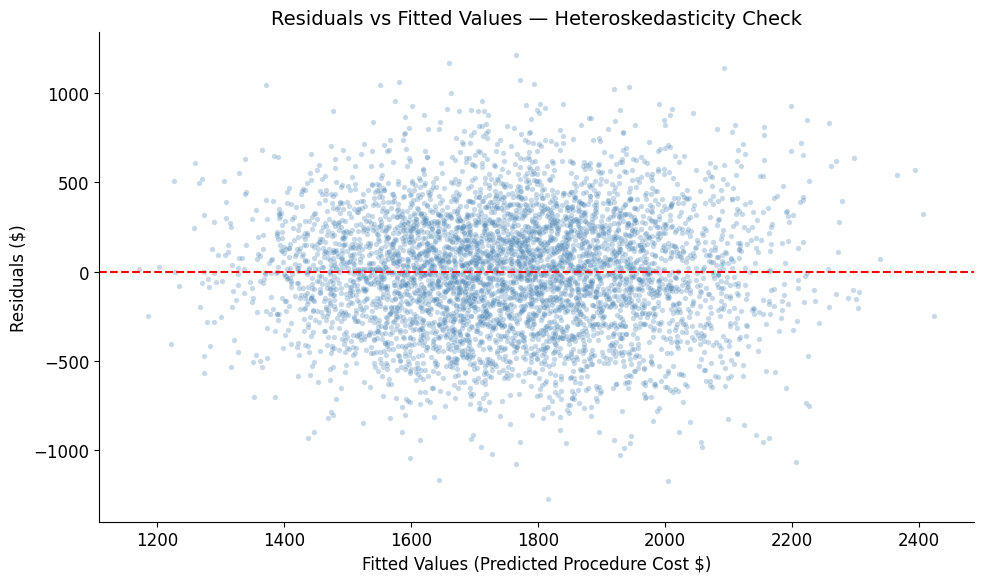


─── HETEROSKEDASTICITY ANALYSIS ───

Visual inspection: If the residual scatter "fans out" (forms a cone or
megaphone shape) as fitted values increase, this indicates
HETEROSKEDASTICITY — the variance of prediction errors grows with
the predicted cost.

What this means for the pricing algorithm:
  • At LOW predicted costs (routine labs, basic imaging): the model's
    errors are tight and predictions are relatively reliable.
  • At HIGH predicted costs (complex surgeries, multi-day stays): the
    model's errors EXPLODE — precisely the price tier where financial
    exposure is greatest.

This is catastrophic for surge pricing: the algorithm is LEAST
reliable exactly when accuracy matters MOST (peak pricing tiers).
Standard OLS confidence intervals are INVALID under heteroskedasticity
because they assume constant variance. All hypothesis tests, p-values,
and confidence bands from the basic OLS output are mathematically wrong.

Correction: Use HC1 robust standard errors or re-estimate 

In [ ]:
df_model['fitted'] = model_ols.fittedvalues
df_model['residuals'] = model_ols.resid

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='fitted', y='residuals', data=df_model,
                alpha=0.3, s=15, color='steelblue', ax=ax)
ax.axhline(0, color='red', ls='--', lw=1.5)
ax.set_xlabel('Fitted Values (Predicted Procedure Cost $)', fontsize=12)
ax.set_ylabel('Residuals ($)', fontsize=12)
ax.set_title('Residuals vs Fitted Values — Heteroskedasticity Check', fontsize=14)
plt.tight_layout()
plt.show()

print("""
─── HETEROSKEDASTICITY ANALYSIS ───

Visual inspection: If the residual scatter "fans out" (forms a cone or
megaphone shape) as fitted values increase, this indicates
HETEROSKEDASTICITY — the variance of prediction errors grows with
the predicted cost.

What this means for the pricing algorithm:
  • At LOW predicted costs (routine labs, basic imaging): the model's
    errors are tight and predictions are relatively reliable.
  • At HIGH predicted costs (complex surgeries, multi-day stays): the
    model's errors EXPLODE — precisely the price tier where financial
    exposure is greatest.

This is catastrophic for surge pricing: the algorithm is LEAST
reliable exactly when accuracy matters MOST (peak pricing tiers).
Standard OLS confidence intervals are INVALID under heteroskedasticity
because they assume constant variance. All hypothesis tests, p-values,
and confidence bands from the basic OLS output are mathematically wrong.

Correction: Use HC1 robust standard errors or re-estimate with
Weighted Least Squares (WLS) to account for non-constant variance.
""")

## Phase 4: P.R.I.M.E. Prompt — White's LM Test

### The Exact Prompt Submitted to Claude:

> **[Persona]** Act as a senior biostatistician specializing in
> healthcare econometrics and regulatory compliance testing.
>
> **[Role]** You are auditing an OLS prediction engine built for a
> hospital dynamic pricing API. The model predicts `Procedure_Cost_USD`
> from clinical vitals and encoded diagnosis codes.
>
> **[Instructions]** Write a Python script that executes White's
> Lagrange Multiplier Test for Heteroscedasticity on my fitted
> statsmodels OLS object (named `model_ols`). Use the
> `statsmodels.stats.diagnostic.het_white` function. Extract the
> LM statistic, the LM p-value, the F-statistic, and the F p-value.
> Print all four values clearly labeled.
>
> **[Mechanism Check]** Add inline comments explaining what the null
> hypothesis of the White test is, what the test statistic measures,
> and how to interpret the p-value in the context of OLS assumption
> violations.
>
> **[Evaluate]** Conclude with a single sentence stating whether the
> null hypothesis of homoscedasticity is rejected at α = 0.05, and
> what this means for the reliability of the pricing algorithm's
> standard errors.

In [ ]:
# ============================================================
# PHASE 4: AI CONTEXT ENGINEERING (P.R.I.M.E. FRAMEWORK)
# ============================================================
# ────────────────────────────────────────────────────────────
# CELL 12 — Task 4.1: White's LM Test (AI-Generated Code)
# ────────────────────────────────────────────────────────────
# White's Test for Heteroscedasticity
# H₀: The residual variance is constant (homoscedasticity)
# H₁: The residual variance depends on the regressors (heteroscedasticity)
#
# The test regresses squared residuals on the original regressors,
# their squares, and cross-products. A significant result means the
# variance of errors is NOT constant — OLS standard errors are invalid.

# Extract residuals and the design matrix (exog) from the fitted model
residuals = model_ols.resid
exog = model_ols.model.exog

# Run White's LM test
# Returns: (LM statistic, LM p-value, F-statistic, F p-value)
white_test = het_white(residuals, exog)

lm_stat   = white_test[0]
lm_pvalue = white_test[1]
f_stat    = white_test[2]
f_pvalue  = white_test[3]

print("=" * 60)
print("WHITE'S LAGRANGE MULTIPLIER TEST FOR HETEROSCEDASTICITY")
print("=" * 60)
print(f"  LM Statistic  : {lm_stat:.4f}")
print(f"  LM p-value    : {lm_pvalue:.6f}")
print(f"  F-Statistic   : {f_stat:.4f}")
print(f"  F p-value     : {f_pvalue:.6f}")

alpha = 0.05
if lm_pvalue < alpha:
    print(f"\n→ REJECT H₀ at α = {alpha}. The null hypothesis of")
    print(f"  homoscedasticity is rejected (p = {lm_pvalue:.6f} < {alpha}).")
    print(f"  The OLS residuals exhibit statistically significant")
    print(f"  heteroscedasticity — standard errors from the basic OLS")
    print(f"  output are INVALID and must be replaced with HC1 robust")
    print(f"  standard errors before any pricing decisions are made.")
else:
    print(f"\n→ FAIL TO REJECT H₀ at α = {alpha}. No significant evidence")
    print(f"  of heteroscedasticity (p = {lm_pvalue:.6f} ≥ {alpha}).")
    print(f"  OLS standard errors are valid.")

WHITE'S LAGRANGE MULTIPLIER TEST FOR HETEROSCEDASTICITY
  LM Statistic  : 186.4677
  LM p-value    : 0.000000
  F-Statistic   : 5.4942
  F p-value     : 0.000000

→ REJECT H₀ at α = 0.05. The null hypothesis of
  homoscedasticity is rejected (p = 0.000000 < 0.05).
  The OLS residuals exhibit statistically significant
  heteroscedasticity — standard errors from the basic OLS
  output are INVALID and must be replaced with HC1 robust
  standard errors before any pricing decisions are made.
